In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
cleaned_df = pd.read_csv('../datasets/cleaned_data/cleaned_cars_info.csv')

In [4]:
df = cleaned_df.copy()
df.head()

,Model year,Make,Model,Vehicle class,Engine size (L),Cylinders,Transmission,Fuel type,Combined (L/100 km),CO2 emissions (g/km)
0,2015,Acura,ILX,Compact,2.0,4,AS5,Z,8.3,191
1,2015,Acura,ILX,Compact,2.4,4,M6,Z,9.3,214
2,2015,Acura,ILX Hybrid,Compact,1.5,4,AV7,Z,6.1,140
3,2015,Acura,MDX SH-AWD,Sport utility vehicle: Small,3.5,6,AS6,Z,11.1,255
4,2015,Acura,RDX AWD,Sport utility vehicle: Small,3.5,6,AS6,Z,10.6,244


**1. Extracting Transmission and Gears using the transmission column**

In [5]:
df['Transmission type'] = df['Transmission'].str.extract(r'([A-Za-z]+)')
df['Gears'] = df['Transmission'].str.extract(r'(\d+)')

In [6]:
df.drop(columns = 'Transmission',inplace = True)

**2. Handling not applicable values**

In [7]:
df['Gears'] = df['Gears'].fillna(0)

Key Point: I split the Transmission column into Transmission Type and Gear. Some transmission types, such as AV, do not have a specific gear number, so the resulting NaN values were replaced with 0 to indicate that the gear count was not applicable.

Here 0 = gear count not applicable.

**3. Handling Outliers(if any)**

**( a ) Engine Size**

In [8]:
numerical_cols = ['Engine size (L)', 'Cylinders', 'Combined (L/100 km)', 'CO2 emissions (g/km)', 'Gears']

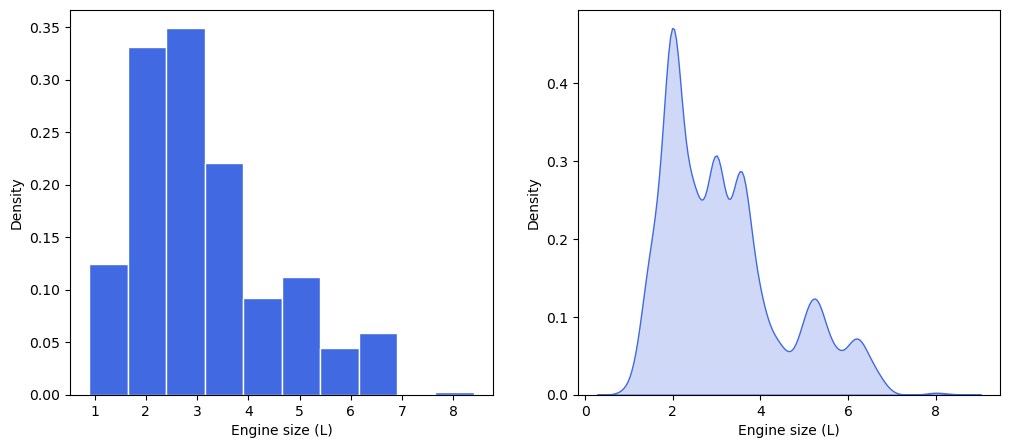

In [9]:
fig, axes = plt.subplots(1,2, figsize = (12,5))

axes[0].hist(df['Engine size (L)'], density = True, color = 'royalblue', edgecolor = 'white')
axes[0].set_xlabel('Engine size (L)')
axes[0].set_ylabel('Density')
sns.kdeplot(data = df, x = 'Engine size (L)', fill = True, color = 'royalblue', ax = axes[1])
plt.show()

Key Point: The distribution is right skewed so i used boxplot to further find the outliers

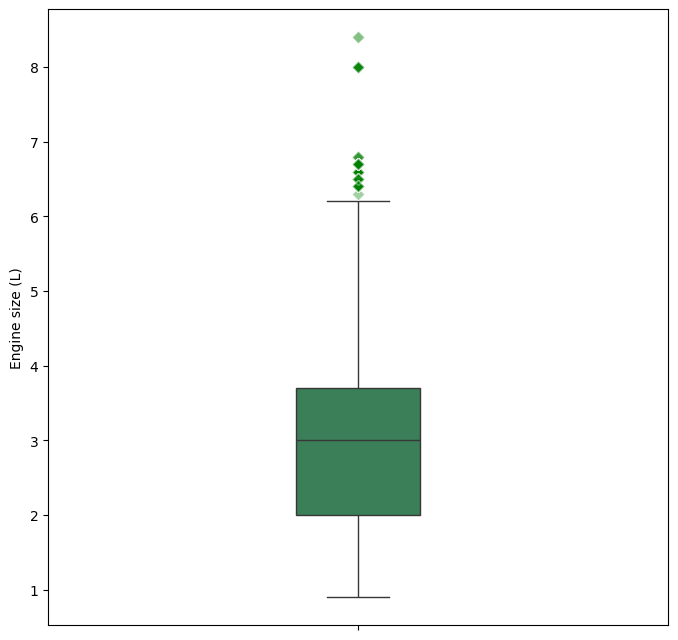

In [10]:
plt.figure(figsize = (8,8))
sns.boxplot(data = df, y = 'Engine size (L)', color = 'seagreen', width = 0.2, flierprops = 
            {'marker': 'D',  
            'markerfacecolor': 'green',
            'markeredgecolor': 'white',
            'markersize': 6,
            'alpha': 0.2
            }
)
plt.show()

In [11]:
df['Engine size (L)'].describe()

count    10060.000000
mean         3.144901
std          1.340010
min          0.900000
25%          2.000000
50%          3.000000
75%          3.700000
max          8.400000
Name: Engine size (L), dtype: float64

In [12]:
percentile25 = df['Engine size (L)'].quantile(0.25)
percentile75 = df['Engine size (L)'].quantile(0.75)
interquartile_range = percentile75 - percentile25
upper_limit = percentile75 + (1.5 * interquartile_range)

outliers = df[df['Engine size (L)'] > upper_limit]['Engine size (L)'].unique()
print('Possible outliers:', [float(x) for x in outliers])

Possible outliers: [6.3, 6.8, 6.4, 8.4, 6.5, 6.6, 6.7, 8.0]


Key point: 
Engine size is positively (right) skewed. The IQR method identified several upper-end outliers. Upon inspection it was confirmed that these values (6.3–8.4 L) are realistic engine sizes for high-performance vehicles. Since they are genuine observations and relevant to CO₂ emissions, they were retained.

**( b ) Cylinders**

In [13]:
df['Cylinders'].unique()

array([ 4,  6, 12,  8, 10,  3,  5, 16])

**( c ) Combined (L/100km)**

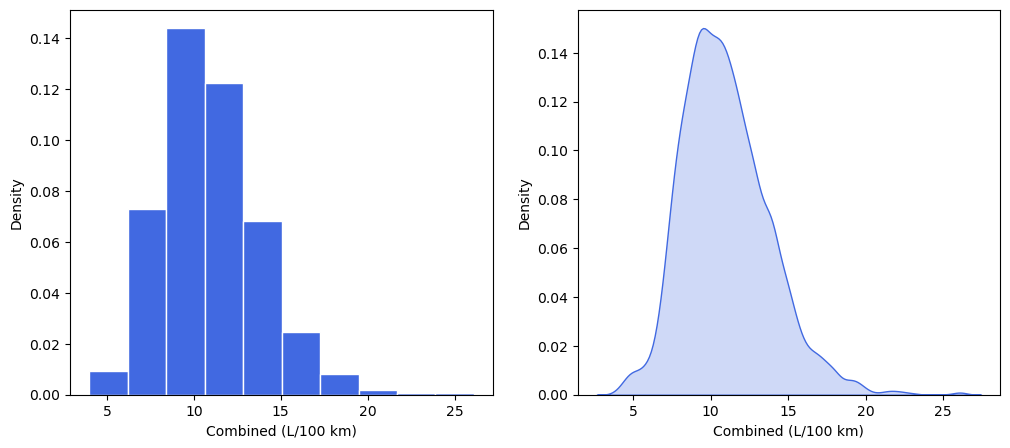

In [14]:
fig, axes = plt.subplots(1,2, figsize = (12,5))

axes[0].hist(df['Combined (L/100 km)'], density = True, color = 'royalblue', edgecolor = 'white')
axes[0].set_xlabel('Combined (L/100 km)')
axes[0].set_ylabel('Density')
sns.kdeplot(data = df, x = 'Combined (L/100 km)', fill = True, color = 'royalblue', ax = axes[1])
plt.show()

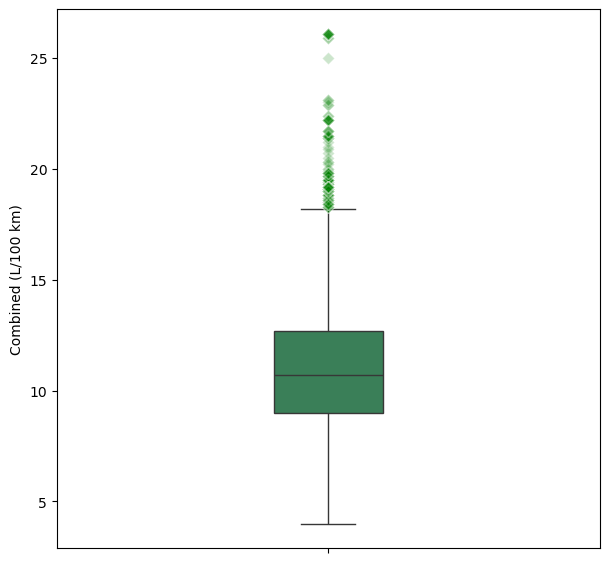

In [15]:
plt.figure(figsize = (7,7))
sns.boxplot(data = df, y = 'Combined (L/100 km)', color = 'seagreen', width = 0.2, flierprops = 
            {'marker': 'D',  
            'markerfacecolor': 'green',
            'markeredgecolor': 'white',
            'markersize': 6,
            'alpha': 0.2
            }
)
plt.show()

In [16]:
percentile25 = df['Combined (L/100 km)'].quantile(0.25)
percentile75 = df['Combined (L/100 km)'].quantile(0.75)
interquartile_range = percentile75 - percentile25
upper_limit = percentile75 + (1.5 * interquartile_range)

outliers = df[df['Combined (L/100 km)'] > upper_limit]['Combined (L/100 km)'].unique()
print('Possible outliers:', sorted([float(x) for x in outliers]))

Possible outliers: [18.3, 18.4, 18.5, 18.6, 18.7, 18.8, 19.0, 19.1, 19.2, 19.3, 19.4, 19.5, 19.6, 19.7, 19.8, 19.9, 20.0, 20.2, 20.3, 20.5, 20.7, 20.9, 21.0, 21.2, 21.4, 21.5, 21.7, 22.2, 22.4, 22.9, 23.0, 23.1, 25.0, 25.9, 26.1]


In [17]:
# pd.set_option('display.max_rows', None)
pd.reset_option('display.max_rows')
outliers = df[df['Combined (L/100 km)'] > upper_limit]
outliers[
    ['Engine size (L)',
     'Cylinders',
     'Combined (L/100 km)',
     'CO2 emissions (g/km)']
].sort_values('Combined (L/100 km)')

,Engine size (L),Cylinders,Combined (L/100 km),CO2 emissions (g/km)
3751,5.3,8,18.3,309
3522,5.3,8,18.3,309
2297,6.8,8,18.3,430
6723,5.0,8,18.3,303
4607,5.3,8,18.4,305
...,...,...,...,...
7511,8.0,16,26.1,608
6532,8.0,16,26.1,608
463,6.0,8,26.1,418
258,6.0,8,26.1,418


Key Point:
The 'Combined (L/100 km)' variable exhibits a right-skewed distribution with several upper-end outliers identified by the IQR method. Inspection indicates that these observations correspond to vehicles with large engine sizes and high CO₂ emissions, suggesting they are genuine observations rather than data errors. Therefore, no outlier treatment was performed.

In [18]:
df.head()

,Model year,Make,Model,Vehicle class,Engine size (L),Cylinders,Fuel type,Combined (L/100 km),CO2 emissions (g/km),Transmission type,Gears
0,2015,Acura,ILX,Compact,2.0,4,Z,8.3,191,AS,5
1,2015,Acura,ILX,Compact,2.4,4,Z,9.3,214,M,6
2,2015,Acura,ILX Hybrid,Compact,1.5,4,Z,6.1,140,AV,7
3,2015,Acura,MDX SH-AWD,Sport utility vehicle: Small,3.5,6,Z,11.1,255,AS,6
4,2015,Acura,RDX AWD,Sport utility vehicle: Small,3.5,6,Z,10.6,244,AS,6


**( d ) CO2 emissions(g/km)**

In [19]:
df['CO2 emissions (g/km)'].nunique()

345

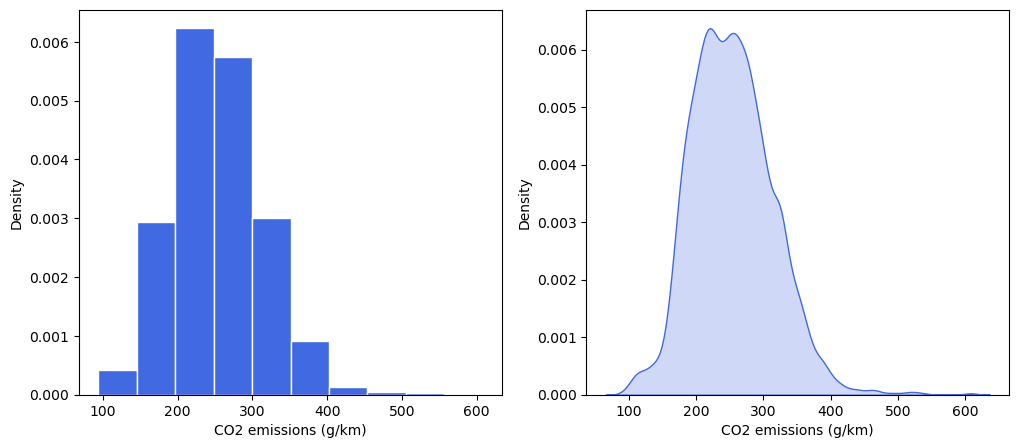

In [20]:
fig, axes = plt.subplots(1,2, figsize = (12,5))

axes[0].hist(df['CO2 emissions (g/km)'], density = True, color = 'royalblue', edgecolor = 'white')
axes[0].set_xlabel('CO2 emissions (g/km)')
axes[0].set_ylabel('Density')
sns.kdeplot(data = df, x = 'CO2 emissions (g/km)', fill = True, color = 'royalblue', ax = axes[1])
plt.show()

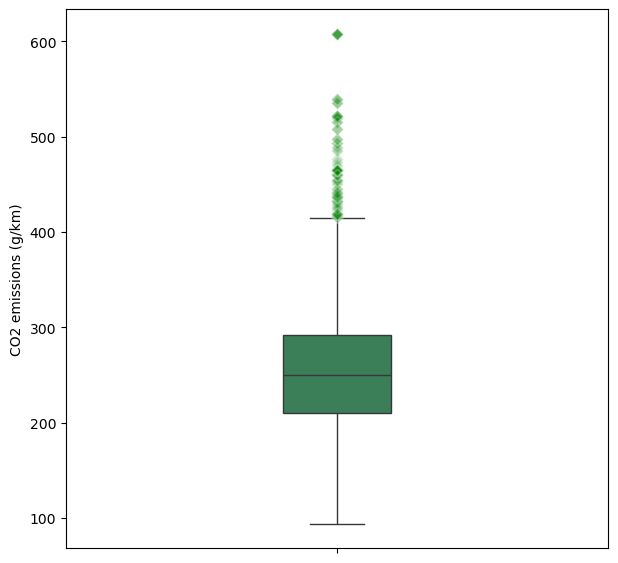

In [21]:
plt.figure(figsize = (7,7))
sns.boxplot(data = df, y = 'CO2 emissions (g/km)', color = 'seagreen', width = 0.2, flierprops = 
            {'marker': 'D',  
            'markerfacecolor': 'green',
            'markeredgecolor': 'white',
            'markersize': 6,
            'alpha': 0.2
            }
)
plt.show()

In [22]:
percentile25 = df['CO2 emissions (g/km)'].quantile(0.25)
percentile75 = df['CO2 emissions (g/km)'].quantile(0.75)
interquartile_range = percentile75 - percentile25
upper_limit = percentile75 + (1.5 * interquartile_range)

outliers = df[df['CO2 emissions (g/km)'] > upper_limit]['CO2 emissions (g/km)'].unique()
print('Possible outliers:', sorted([float(x) for x in outliers]))

Possible outliers: [416.0, 417.0, 418.0, 419.0, 420.0, 423.0, 425.0, 426.0, 428.0, 430.0, 432.0, 436.0, 437.0, 438.0, 440.0, 441.0, 442.0, 445.0, 450.0, 452.0, 453.0, 454.0, 460.0, 461.0, 464.0, 465.0, 467.0, 470.0, 473.0, 476.0, 485.0, 487.0, 489.0, 493.0, 498.0, 508.0, 515.0, 520.0, 522.0, 535.0, 537.0, 539.0, 608.0]


In [23]:
# pd.set_option('display.max_rows', None)
pd.reset_option('display.max_rows')
outliers = df[df['CO2 emissions (g/km)'] > upper_limit]
outliers[
    ['Engine size (L)',
     'Cylinders',
     'Combined (L/100 km)',
     'CO2 emissions (g/km)']
].sort_values('CO2 emissions (g/km)')

,Engine size (L),Cylinders,Combined (L/100 km),CO2 emissions (g/km)
255,4.8,8,18.1,416
460,4.8,8,18.1,416
1894,5.5,8,18.5,417
463,6.0,8,26.1,418
258,6.0,8,26.1,418
...,...,...,...,...
8482,8.0,16,26.1,608
7510,8.0,16,26.1,608
7511,8.0,16,26.1,608
8483,8.0,16,26.1,608


The CO₂ emissions (g/km) variable contains 345 unique values, indicating that it behaves as a continuous numerical variable despite being recorded as integers. Therefore, histogram and boxplot visualizations were used, and outliers were assessed using the IQR method. The identified upper-end outliers represent genuine high-emission vehicles and were retained for analysis.

**4. Dropping the Model column**

In [27]:
df.drop(columns = 'Model', inplace = True)

**5. Export**

In [28]:
df.to_csv('../datasets/feature_engineered_data/feature_engineered_cars.csv', index = False)